In [1]:
import os
import random
import h5py

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary
from sklearn.metrics import r2_score
import plotly.express as px


from sklearn.preprocessing import LabelEncoder

import torchvision.transforms.functional as TF

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

generator = torch.Generator().manual_seed(SEED)

# Set the device to use for training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Data

In [2]:
folder_path = "models/"

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if not os.path.exists(os.path.join(folder_path, "checkpoints")):
    os.makedirs(os.path.join(folder_path, "checkpoints"))

- Reading files

In [3]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": types_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

In [4]:
path = "../src/data/processed/disaster.h5"
df_disaster = read_hdf5_to_dataframe_with_index(path)

path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

# combine the two dataframes
df = pd.concat([df_disaster, df_idu], ignore_index=True)

In [6]:
del df_disaster
del df_idu

In [8]:
len(df)

16896

- load iso3 embedding

In [9]:
# load csv iso3 embeddings
iso3_embeddings = pd.read_csv("../src/data/processed/embeddings_iso3_3d_mapped.csv", index_col=0)

In [10]:
iso3_embeddings.head()

,emb_0,emb_1,emb_2
iso3_mapped,,,
AND,-2.155526,-0.099045,1.090775
ARE,-2.354902,-0.086402,1.196469
AFG,2.381075,-0.013857,-0.791427
ATG,-0.600651,-0.696483,-1.296734
ALB,0.138654,-0.234058,-0.686938


In [11]:
def plot_iso3_distribution(df):
    iso3_counts = df["iso3"].value_counts().reset_index()
    iso3_counts.columns = ["iso3", "count"]
    iso3_counts["log_count"] = np.log1p(iso3_counts["count"])
    top_10 = iso3_counts.nlargest(10, "count").sort_values("count")

    # Figure 1: global choropleth
    fig_map = px.choropleth(
        iso3_counts,
        locations="iso3",
        color="log_count",
        hover_name="iso3",
        hover_data={"count": ":.0f", "log_count": False},
        color_continuous_scale="Magma",
        title="<b>Climate related disaster concentration by country</b><br><sub>Global map</sub>",
    )
    fig_map.update_geos(
        projection_type="equirectangular",
        lataxis_range=[-58, 90],
        showframe=False,
        showcoastlines=False,
        showland=True,
        landcolor="rgb(245,245,245)",
    )
    fig_map.update_layout(
        template="simple_white",
        title=dict(x=0.5, xanchor="center"),
        height=620,
        width=1100,
        margin=dict(l=20, r=20, t=80, b=10),
        font=dict(size=12),
        coloraxis_colorbar=dict(
            title="Log events",
            thickness=12,
            len=0.7,
        ),
    )
    fig_map.show()

    # Figure 2: top countries bar chart
    fig_bar = px.bar(
        top_10,
        y="iso3",
        x="count",
        orientation="h",
        color="count",
        color_continuous_scale="Magma",
        title="<b>Climate related disasters by country</b>",
        labels={"iso3": "Country", "count": "Events"},
    )
    fig_bar.update_traces(
        cliponaxis=False,
        marker_line_color="rgba(0,0,0,0.08)",
        marker_line_width=1,
    )
    fig_bar.update_layout(
        template="simple_white",
        title=dict(x=0.5, xanchor="center"),
        height=520,
        width=760,
        margin=dict(l=20, r=30, t=80, b=20),
        font=dict(size=12),
        showlegend=False,
        xaxis=dict(showgrid=True, gridcolor="rgba(0,0,0,0.08)", title="Events"),
        yaxis=dict(title="", automargin=True),
    )
    fig_bar.show()

    print(f"Top 10 countries account for {top_10['count'].sum() / iso3_counts['count'].sum() * 100:.1f}% of events")
    print(", ".join(top_10["iso3"].tolist()))


plot_iso3_distribution(df)

Top 10 countries account for 54.5% of events
LKA, MYS, PHL, USA, BDI, IND, IDN, BRA, SOM, PER


# Simple baseline


=== EMBEDDING MODEL ===
{'R2': 0.29252803325653076, 'MAE': 1.6457843780517578, 'RMSE': np.float64(2.114547603912919)}

=== FULL MODEL ===
{'R2': 0.42056286334991455, 'MAE': 1.4659512042999268, 'RMSE': np.float64(1.9136654811860554)}

=== TOP FEATURES ===
   feature  importance_mean  importance_std              display_name
25    ve_2         0.171260        0.013708             VIIRS end min
2    emb_2         0.114007        0.009537  Country embedding: emb_2
0    emb_0         0.109995        0.008038  Country embedding: emb_0
15    vs_0         0.100252        0.005298          VIIRS start mean
1    emb_1         0.099615        0.005886  Country embedding: emb_1
16    vs_1         0.079460        0.005637           VIIRS start std
21    vs_6         0.075336        0.006616          VIIRS start 75th
30    ve_7         0.071164        0.005656             VIIRS end ptp
29    ve_6         0.062486        0.004171            VIIRS end 75th
17    vs_2         0.056888        0.004519 

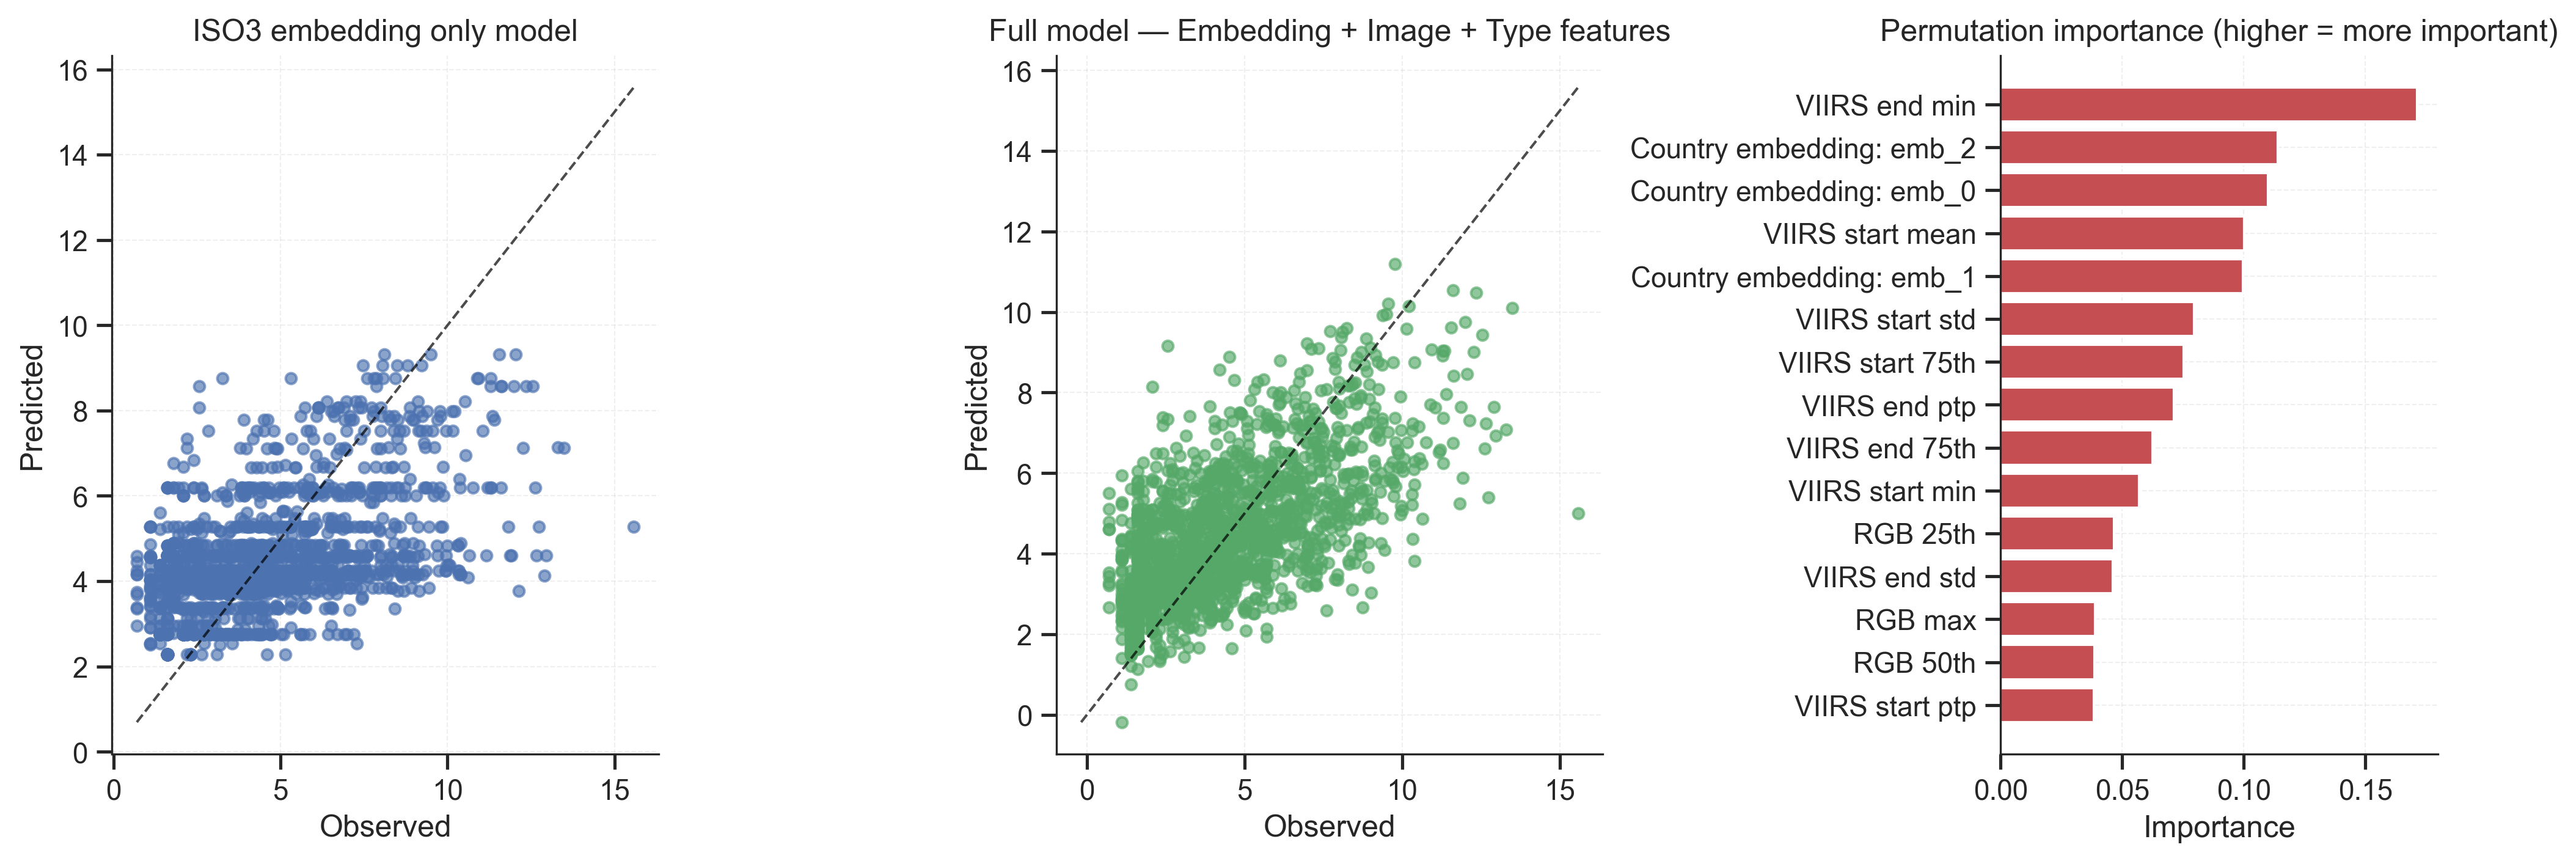

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor


# =========================================================
# CONFIG
# =========================================================
RANDOM_STATE = 42
TEST_SIZE = 0.1


# =========================================================
# ---------------- DATA + FEATURES ----------------
# =========================================================
def extract_image_statistics(image_array):
    if image_array is None or len(image_array) == 0:
        return np.zeros(8)

    try:
        img = np.array(image_array)
        if img.size == 0:
            return np.zeros(8)

        flat = img.flatten()
        return np.array([
            np.mean(flat),
            np.std(flat),
            np.min(flat),
            np.max(flat),
            np.percentile(flat, 25),
            np.percentile(flat, 50),
            np.percentile(flat, 75),
            np.ptp(flat)
        ])
    except:
        return np.zeros(8)


def build_image_features(df):
    def build(col, prefix):
        stats = df[col].apply(extract_image_statistics)
        arr = np.array(stats.tolist())
        return pd.DataFrame(arr, columns=[f"{prefix}_{i}" for i in range(8)])

    return pd.concat([
        build("viirs_start", "vs"),
        build("viirs_end", "ve"),
        build("rgb", "rgb")
    ], axis=1)


def build_feature_matrices(df, iso3_embeddings):

    embedding_df = iso3_embeddings.reset_index().rename(
        columns={iso3_embeddings.index.name or "index": "iso3"}
    )

    merged = df[["iso3", "figures", "viirs_start", "viirs_end", "rgb", "type"]].copy()
    merged = merged.merge(embedding_df, on="iso3", how="inner")

    embed_cols = [c for c in embedding_df.columns if c != "iso3"]
    X_embed = merged[embed_cols].to_numpy(np.float32)

    type_dummies = pd.get_dummies(merged["type"], prefix="type")
    merged = pd.concat([merged, type_dummies], axis=1)

    img_features = build_image_features(merged)
    merged = pd.concat([merged, img_features], axis=1)

    img_cols = list(img_features.columns)
    type_cols = list(type_dummies.columns)

    full_cols = embed_cols + type_cols + img_cols
    X_full = merged[full_cols].to_numpy(np.float32)

    y = merged["figures"].to_numpy(np.float32)

    return X_embed, X_full, y, embed_cols, full_cols


# =========================================================
# ---------------- MODEL TRAINING ----------------
# =========================================================
def train_xgb_model(X_train, y_train_log, X_val, y_val_log):

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=100
    )

    model.fit(
        X_train,
        y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False
    )

    return model


def predict(model, X):
    return model.predict(X)


# =========================================================
# ---------------- EVALUATION ----------------
# =========================================================
def evaluate(y_true_log, y_pred_log):
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE": np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    }


def human_readable_feature_names(feature_names):
    stat_map = {
        0: "mean",
        1: "std",
        2: "min",
        3: "max",
        4: "25th",
        5: "50th",
        6: "75th",
        7: "ptp",
    }

    def _readable(f):
        if isinstance(f, int):
            return f"Embedding_{f}"
        if f.startswith("type_"):
            return f"Type: {f[len('type_'):]}"

        # image feature prefixes used in build_image_features
        for prefix, label in [("vs", "VIIRS start"), ("ve", "VIIRS end"), ("rgb", "RGB")]:
            if f.startswith(prefix + "_"):
                try:
                    idx = int(f.split("_")[1])
                    return f"{label} {stat_map.get(idx, idx)}"
                except Exception:
                    return f"{label} {f.split('_',1)[1]}"

        # fallback: assume embedding or generic feature
        return f"Country embedding: {f}"

    return [ _readable(f) for f in feature_names ]


def permutation_importance_df(model, X_test, y_test_log, feature_names):
    result = permutation_importance(
        model,
        X_test,
        y_test_log,
        n_repeats=15,
        random_state=RANDOM_STATE,
        scoring="r2",
    )

    df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    })

    # add human readable labels for plotting
    df["display_name"] = human_readable_feature_names(df["feature"].tolist())

    return df.sort_values("importance_mean", ascending=False)


# =========================================================
# ---------------- PIPELINE ----------------
# =========================================================
def train_models(X_embed, X_full, y):

    y_log = np.log1p(y)

    Xe_train, Xe_test, y_train, y_test = train_test_split(
        X_embed, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    Xf_train, Xf_test, _, _ = train_test_split(
        X_full, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # ---- Embedding model
    embed_model = train_xgb_model(Xe_train, y_train, Xe_test, y_test)
    y_pred_embed = predict(embed_model, Xe_test)

    # ---- Full model
    full_model = train_xgb_model(Xf_train, y_train, Xf_test, y_test)
    y_pred_full = predict(full_model, Xf_test)

    metrics_embed = evaluate(y_test, y_pred_embed)
    metrics_full = evaluate(y_test, y_pred_full)

    return {
        "embed_model": embed_model,
        "full_model": full_model,
        "X_test_embed": Xe_test,
        "X_test_full": Xf_test,
        "y_test": y_test,
        "y_pred_embed": y_pred_embed,
        "y_pred_full": y_pred_full,
        "metrics_embed": metrics_embed,
        "metrics_full": metrics_full
    }


# =========================================================
# ---------------- PLOTTING (NATURE STYLE) ----------------
# =========================================================
def plot_results(results, perm_importance, top_n=15):

    y_true = results["y_test"]
    y_embed = results["y_pred_embed"]
    y_full = results["y_pred_full"]

    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "axes.linewidth": 0.8
    })

    fig = plt.figure(figsize=(13.5, 4.8), dpi=300)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 0.8], figure=fig)

    def style(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
        ax.set_axisbelow(True)

    # ---------------- Embedding ----------------
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.scatter(y_true, y_embed, s=18, alpha=0.65, color="#4C72B0")

    lims = [min(y_true.min(), y_embed.min()),
            max(y_true.max(), y_embed.max())]
    ax0.plot(lims, lims, "--", color="black", linewidth=1, alpha=0.7)

    ax0.set_title("ISO3 embedding only model")
    ax0.set_xlabel("Observed")
    ax0.set_ylabel("Predicted")
    style(ax0)

    # ---------------- Full model ----------------
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.scatter(y_true, y_full, s=18, alpha=0.65, color="#55A868")

    lims = [min(y_true.min(), y_full.min()),
            max(y_true.max(), y_full.max())]
    ax1.plot(lims, lims, "--", color="black", linewidth=1, alpha=0.7)

    ax1.set_title("Full model — Embedding + Image + Type features")
    ax1.set_xlabel("Observed")
    ax1.set_ylabel("Predicted")
    style(ax1)

    # ---------------- Importance ----------------
    ax2 = fig.add_subplot(gs[0, 2])

    top = perm_importance.head(top_n).iloc[::-1]

    # use human readable display names when available
    label_col = "display_name" if "display_name" in perm_importance.columns else "feature"
    ax2.barh(top[label_col], top["importance_mean"], color="#C44E52")

    ax2.set_title("Permutation importance")
    ax2.set_xlabel("Importance")
    style(ax2)

    plt.tight_layout()
    plt.show()


# =========================================================
# ---------------- RUN PIPELINE ----------------
# =========================================================
def run_pipeline(df, iso3_embeddings):

    X_embed, X_full, y, embed_cols, full_cols = build_feature_matrices(
        df, iso3_embeddings
    )

    results = train_models(X_embed, X_full, y)

    print("\n=== EMBEDDING MODEL ===")
    print(results["metrics_embed"])

    print("\n=== FULL MODEL ===")
    print(results["metrics_full"])

    perm_importance = permutation_importance_df(
        results["full_model"],
        results["X_test_full"],
        results["y_test"],
        full_cols
    )

    print("\n=== TOP FEATURES ===")
    print(perm_importance.head(20))

    plot_results(results, perm_importance)

    return results, perm_importance


# =========================================================
# RUN
# =========================================================
results, perm_importance = run_pipeline(df, iso3_embeddings)

# NN

- Architecture

In [ ]:
class MultiBranchCNN(nn.Module):
    def __init__(self, output_dim=1):
        super(MultiBranchCNN, self).__init__()

        # === ResNet-50 Feature Extractor ===
        self.rgb_model = models.resnet50(pretrained=True)
        for param in self.rgb_model.parameters():
            param.requires_grad = True
        self.rgb_model.fc = nn.Identity()
        rgb_output_dim = 2048

        # === RGB Projection Head ===
        self.rgb_proj = nn.Sequential(
            nn.Linear(rgb_output_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),  # final output is 64
            nn.ReLU(),
        )

        # === VIIRS CNN Branch ===
        self.viirs_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (32, H, W)
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # Downsample
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # Output: (64, 1, 1)
            nn.Flatten(),  # Final output: (64,)
        )

        # === Fusion MLP ===
        self.mlp = nn.Sequential(
            nn.Linear(64 + 64 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
        )

    def forward(
        self, rgb_img, viirs_img, country_embedding
    ):  # country_embedding is (batch_size, 64)
        rgb_feat = self.rgb_model(rgb_img)
        rgb_proj = self.rgb_proj(rgb_feat)  # (batch_size, 64)

        viirs_feat = self.viirs_cnn(viirs_img)  # (batch_size, 64)

        fused = torch.cat(
            [rgb_proj, viirs_feat, country_embedding], dim=1
        )  # (batch_size, 192)
        output = self.mlp(fused)
        return output.squeeze(1)  # for regression; remove this for classification


- Hyperparameters
    - last I used is 1e-5, 64 batch
    

In [ ]:
batch_size = 64  # we reached .7 training on this .15 for test (64, and 1e-5 works too)
learning_rate = 1e-3 # e-5 was fine , batch size 32 (.37 train, .09 test)
weight_decay = 1e-4 # -5 is fine. 
num_epochs = 400

- Transform

In [ ]:
target_size = (224, 224)  # Define the target size for resizing images

class JointTransform:
    def __init__(self, target_size=target_size):
        self.target_size = target_size
        self.resize_rgb = transforms.Resize(
            target_size, interpolation=transforms.InterpolationMode.BILINEAR, antialias=False
        )
        self.color_jitter = transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        )
        self.normalize_rgb = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )
        self.normalize_viirs = transforms.Normalize(mean=[0], std=[1])

    def __call__(self, rgb, viirs):
        # Resize only RGB (PIL)
        rgb = self.resize_rgb(rgb)
        rgb = self.color_jitter(rgb)
        
        # Random horizontal flip
        if random.random() > 0.5:
            rgb = TF.hflip(rgb)
            viirs = TF.hflip(viirs)

        # Random vertical flip
        if random.random() > 0.5:
            rgb = TF.vflip(rgb)
            viirs = TF.vflip(viirs)

        # Normalize
        rgb = self.normalize_rgb(rgb)
        # viirs = self.normalize_viirs(viirs)

        return rgb, viirs


- Dataset and DataLoader

In [ ]:
class IDPDataset(Dataset):
    def __init__(self, df, joint_transform=None):
        self.df = df
        self.joint_transform = joint_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        viirs = (
            torch.tensor(self.df.iloc[idx]["viirs_diff"]).float().squeeze().to(device)
        )

        if viirs.ndim == 2:
            viirs = viirs.unsqueeze(0)  # (1, H, W)

        rgb = torch.tensor(self.df.iloc[idx]["rgb"]).float().squeeze().to(device)

        target = torch.tensor(self.df.iloc[idx]["figures"]).float().to(device)
        iso3 = self.df.iloc[idx]["iso3"]
        iso3_emb = torch.tensor(self.df.iloc[idx]["iso3_encoded"]).to(device)

        if self.joint_transform:
            rgb, viirs = self.joint_transform(rgb, viirs)

        return rgb, viirs, target, iso3, iso3_emb

In [ ]:
# Create the transform
joint_transform = JointTransform(target_size=(224, 224))

# Create the dataset
dataset = IDPDataset(df=df, joint_transform=joint_transform)

In [ ]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)

- Data split

In [ ]:
def create_data_loaders(dataset, batch_size, generator, split_ratio=(0.8, 0.1, 0.1)):
    assert sum(split_ratio) == 1.0, "Split ratios must sum to 1.0"

    total = len(dataset)
    train_size = int(split_ratio[0] * total)
    val_size = int(split_ratio[1] * total)
    test_size = total - train_size - val_size  # Ensure full coverage

    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size], generator=generator
)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False),
)

In [ ]:
train_loader, val_loader, test_loader = create_data_loaders(
    dataset, batch_size, generator
)

- Initiate model, loss and optimizer

In [ ]:
model = MultiBranchCNN(output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# scheduler = ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=5, verbose=True
# )

In [ ]:
summary(
    model,
    input_size=(
        ( batch_size, 3, 224, 224),
        ( batch_size, 1, 20, 20),
        ( batch_size, 64)
    ),
    device=device.type,
)

# Training

In [ ]:
train_size = len(train_loader.dataset)
val_size = len(val_loader.dataset)

In [ ]:
best_loss = float("inf")
patience = 10
patience_counter = 0
train_losses = []
val_losses = []

print(f"Training on {train_size} examples, validating on {val_size} examples")

for epoch in range(num_epochs):

    for param_group in optimizer.param_groups:
        print(f"Current learning rate: {param_group['lr']}")
        
    # Training phase
    model.train()
    epoch_train_loss = 0.0

    for rgb, viirs, targets, _ , iso3_emb in train_loader:
        # Move data to device
        rgb = rgb.to(device)
        viirs = viirs.to(device)
        targets = targets.to(device)
        iso3_emb = iso3_emb.to(device)

        # Forward pass
        outputs = model(rgb, viirs, iso3_emb)
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for rgb, viirs, targets, _, iso3_emb in val_loader:
            rgb = rgb.to(device)
            viirs = viirs.to(device)
            targets = targets.to(device)
            iso3_emb = iso3_emb.to(device)

            outputs = model(rgb, viirs, iso3_emb)
            val_loss = criterion(outputs, targets)
            epoch_val_loss += val_loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    # scheduler.step(epoch_val_loss)

    # Print epoch statistics
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}"
    )

    # Early stopping
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), folder_path + "checkpoints/best_model_gidd.pth")
        print(f" ✅ Saved with validation loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# if using ReduceLROnPlateau, restore lr
if "scheduler" in locals():
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate  # Reset learning rate to initial value

# Load best model

- Inference using best model

In [ ]:
model.load_state_dict(torch.load(folder_path + "checkpoints/best_model_gidd.pth"))

In [ ]:
def predict_batch(model, batch, device):
    """Processes a single batch and returns predictions and targets."""
    rgb, viirs, target, _, iso3_emb = batch
    rgb = rgb.to(device)
    viirs = viirs.to(device)
    iso3_emb = iso3_emb.to(device)

    output = model(rgb, viirs, iso3_emb)
    return output.cpu().numpy(), target.cpu().numpy()


def get_predictions_and_targets(model, dataloader, device):
    """Gets predictions and targets for the entire dataloader."""
    model.eval()
    predictions, targets = [], []

    with torch.no_grad():
        for batch in dataloader:
            batch_preds, batch_targets = predict_batch(model, batch, device)
            predictions.extend(batch_preds)
            targets.extend(batch_targets)

    return np.array(predictions), np.array(targets)


def plot_scatter(ax, targets, predictions, title):
    """Plots a scatter plot with predictions vs targets."""
    r2 = r2_score(targets, predictions)
    ax.scatter(targets, predictions, alpha=0.3)
    ax.plot(
        [targets.min(), targets.max()],
        [targets.min(), targets.max()],
        "r--",
        lw=2,
    )
    ax.set_title(f"{title}\n$R^2$ = {r2:.4f}")
    ax.set_xlabel("True IDP")
    ax.set_ylabel("Predicted IDP")


def plot_predictions_vs_targets(
    model, device, *data_loaders, save=False, save_path="predictions_vs_targets.pdf"
):

    num_sets = len(data_loaders)
    fig, axes = plt.subplots(
        1, num_sets, figsize=(7 * num_sets, 6), sharex=True, sharey=True
    )

    if num_sets == 1:
        axes = [axes] 

    for ax, (label, loader) in zip(axes, data_loaders):
        preds, targets = get_predictions_and_targets(model, loader, device)
        plot_scatter(ax, targets, preds, f"{label} Set")

    # plt.suptitle("Predictions vs Targets")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, format=save_path.split(".")[-1], bbox_inches="tight")
        print(f"Plot saved to: {os.path.abspath(save_path)}")
        plt.show(block=False)  # Show the plot without blocking
        plt.close()
    else:
        plt.show()

In [ ]:
plot_predictions_vs_targets(
    model, device, ("Train", train_loader), ("Test", test_loader), save=True, save_path="predictions_vs_targets.pdf"
)

In [ ]:
plot_predictions_vs_targets(model, device, ("Test", test_loader), save=True, save_path="scatter_idmc.pdf")

# IDU

In [ ]:
path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

In [ ]:
df_idu, le_idu, emb_idu = replace_iso3_with_embedding(df_idu)
df_idu = create_viirs_diff_column(df_idu)
df_idu = log_and_normalize_column(df_idu, "figures")

In [ ]:
dataset_idu = IDPDataset(df=df_idu, joint_transform=joint_transform)

In [ ]:
dataloader_idu = DataLoader(dataset_idu, batch_size=batch_size, shuffle=True, generator=generator)

In [ ]:
# split the dataset into train, val, test
train_loader_idu, val_loader_idu, test_loader_idu = create_data_loaders(dataset_idu, batch_size, generator)

In [ ]:
train_size_idu = len(train_loader_idu.dataset)
val_size_idu = len(val_loader_idu.dataset)
test_size_idu = len(test_loader_idu.dataset)

- Fine-tuning

In [ ]:
# finetune model on idu
best_loss = float("inf")
patience = 10
patience_counter = 0
train_losses = []
val_losses = []

print(f"Training on {train_size_idu} examples, validating on {val_size_idu} examples")

for epoch in range(num_epochs):
    for param_group in optimizer.param_groups:
        print(f"Current learning rate: {param_group['lr']}")

    # Training phase
    model.train()
    epoch_train_loss = 0.0

    for rgb, viirs, targets, _, iso3_emb in train_loader_idu:
        # Move data to device
        rgb = rgb.to(device)
        viirs = viirs.to(device)
        targets = targets.to(device)
        iso3_emb = iso3_emb.to(device)

        # Forward pass
        outputs = model(rgb, viirs, iso3_emb)
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for rgb, viirs, targets, _, iso3_emb in val_loader_idu:
            rgb = rgb.to(device)
            viirs = viirs.to(device)
            targets = targets.to(device)
            iso3_emb = iso3_emb.to(device)

            outputs = model(rgb, viirs, iso3_emb)
            val_loss = criterion(outputs, targets)
            epoch_val_loss += val_loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    # scheduler.step(epoch_val_loss)

    # Print epoch statistics
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}"
    )

    # Early stopping
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), folder_path + "checkpoints/best_model_idu.pth")
        print(f" ✅ Saved with validation loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

In [ ]:
plot_predictions_vs_targets(model, device, ("Test", test_loader_idu), save=True, save_path="scatter_idu.pdf")

In [ ]:
# combine test_loader and test_loader_idu into one dataloader and plot predictions vs targets for both
combined_dataset = torch.utils.data.ConcatDataset([test_loader.dataset, test_loader_idu.dataset])
combined_test_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=False)

- Per country error

In [ ]:
def evaluate_per_country(model, dataloader):
    model.eval()
    country_predictions = {}
    country_targets = {}

    with torch.no_grad():
        for rgb, viirs, target, iso, iso3_emb in dataloader:
            rgb = rgb.to(device)
            viirs = viirs.to(device)
            iso3_emb = iso3_emb.to(device)  # keep on same device as model
            output = model(rgb, viirs, iso3_emb)

            output_cpu = output.cpu()
            target_cpu = target.cpu()

            for i in range(len(iso)):
                code = iso[i]
                if code not in country_predictions:
                    country_predictions[code] = []
                    country_targets[code] = []
                country_predictions[code].append(output_cpu[i].item())
                country_targets[code].append(target_cpu[i].item())

    return country_predictions, country_targets


country_predictions, country_targets = evaluate_per_country(model, combined_test_loader)

country_mae = {
    iso3: np.mean(
        np.abs(
            np.array(country_predictions[iso3], dtype=np.float32)
            - np.array(country_targets[iso3], dtype=np.float32)
        )
    )
    for iso3 in country_predictions
}

mae_df = pd.DataFrame({"iso3": list(country_mae.keys()), "mae": list(country_mae.values())})
mae_df = mae_df[mae_df["iso3"] != "ATA"]  # optional

fig = px.choropleth(
    mae_df,
    locations="iso3",
    color="mae",
    hover_name="iso3",
    color_continuous_scale="Reds",
)

fig.update_geos(
    showframe=False,
    showcoastlines=False,
    projection_type="equirectangular",
    lataxis_range=[-58, 90],  # hides Antarctica
)
fig.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})

fig.show()

# save as pdf
fig.write_image("mae_per_country.pdf", format="pdf", scale=2)


In [ ]:
# which countries have the highest MAE
highest_mae_countries = mae_df.sort_values(by="mae", ascending=False).head(20)
print("Countries with the highest MAE:")
print(highest_mae_countries)

In [ ]:
# see overlapping countries that are highest MAE and least represented in df
overlapping_countries = set(highest_mae_countries["iso3"]).intersection(
    set(list_least_frequent_iso3(df, threshold=20)))

In [ ]:
list_least_frequent_iso3(df, threshold=20)